<a href="https://colab.research.google.com/github/pratyushadhikary2004-ship-it/LOAN_PREDICTION_MODEL_final/blob/main/LOAN_PREDICTION_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pickle

In [9]:
df = pd.read_csv("loan_data_new.csv")

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (45000, 14)


,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [10]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB
None


In [11]:
print(df.isnull().sum())

Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64


In [12]:
print(df["Loan Status"].value_counts())

Loan Status
0    35000
1    10000
Name: count, dtype: int64


In [13]:
X = df.drop("Loan Status", axis=1)
y = df["Loan Status"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (45000, 13)
Target shape: (45000,)


In [15]:
numerical_columns = [
    "Age",
    "Person Income",
    "Employee Experience",
    "Loan Amount",
    "Loan interest Rate",
    "Loan percentage",
    "Credit History",
    "Credit Score"
]

In [16]:
categorical_columns = [
    "Gender",
    "Education",
    "Home Onwership",
    "Loan Intent",
    "Previous Loan"
]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36000, 13)
Testing data: (9000, 13)


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

In [19]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [20]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [21]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.8993333333333333
Accuracy Percentage: 89.93333333333334 %


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [24]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6600  400]
 [ 506 1494]]


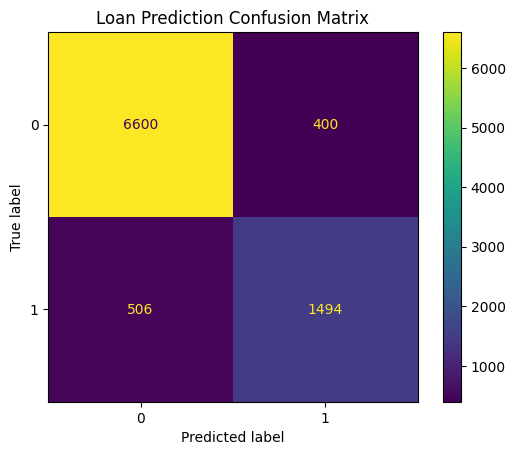

In [25]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Loan Prediction Confusion Matrix")
plt.show()

In [26]:
probabilities = model.predict_proba(X_test)

print(probabilities[:5])

[[9.74877609e-01 2.51223908e-02]
 [9.99966413e-01 3.35871405e-05]
 [9.99998262e-01 1.73750493e-06]
 [9.99976447e-01 2.35530149e-05]
 [5.34474212e-01 4.65525788e-01]]


In [27]:
with open("loan_prediction_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")


Model saved successfully!


In [28]:
sample = pd.DataFrame({
    "Age": [25],
    "Gender": ["male"],
    "Education": ["Bachelor"],
    "Person Income": [50000],
    "Employee Experience": [3],
    "Home Onwership": ["RENT"],
    "Loan Amount": [10000],
    "Loan Intent": ["PERSONAL"],
    "Loan interest Rate": [10.5],
    "Loan percentage": [20.0],
    "Credit History": [1],
    "Credit Score": [700],
    "Previous Loan": ["No"]
})

In [29]:
prediction = model.predict(sample)

probability = model.predict_proba(sample)[0][1]

print("Prediction:", prediction[0])
print("Approval Probability:", probability * 100, "%")

Prediction: 1
Approval Probability: 100.0 %


In [30]:
for column in df.select_dtypes(include="object").columns:
    print("\n", column)
    print(df[column].unique())


 Gender
['female' 'male']

 Education
['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']

 Home Onwership
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

 Loan Intent
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

 Previous Loan
['No' 'Yes']
